# Learning Algorithms

Notebook này trình bày quy trình thực hành trực tiếp cho nhóm **Learning Algorithms** trên bài toán **Grid-world Navigation 8x8**. Mục tiêu không chỉ là chạy thuật toán, mà còn hiểu rõ cách agent học từ trải nghiệm, cách cập nhật value function hoặc action-value function, cách dùng baseline đúng vai trò để đánh giá, và cách đọc các metrics như return, TD error, success rate, trap rate, MSE và policy agreement.

Khác với nhóm **Planning Algorithms**, các thuật toán Learning trong notebook này **không giả định agent biết trước mô hình đầy đủ của môi trường**. Trong quá trình training, agent không dùng trực tiếp $P(s' \mid s,a)$ hay $r(s,a,s')$. Thay vào đó, agent chỉ quan sát các sample thu được khi tương tác với môi trường:

$$
(S_t, A_t, R_{t+1}, S_{t+1})
$$

Trong đó $S_t$ là trạng thái hiện tại, $A_t$ là hành động agent thực hiện, $R_{t+1}$ là reward nhận được, và $S_{t+1}$ là trạng thái kế tiếp mà môi trường trả về.

Vì chỉ học từ sample, Learning Algorithms dùng interface tương tác:

```python
env.reset()
env.step(action)
```

và trong quá trình training **không dùng**:

```python
env.get_transitions(state, action)
```

Điểm này là khác biệt nền tảng giữa Planning và Learning. Planning tính kỳ vọng trực tiếp trên toàn bộ transition model; Learning phải ước lượng giá trị hoặc policy thông qua dữ liệu sinh ra từ nhiều episode. Do đó, kết quả Learning thường có dao động theo seed, hyperparameters, số episode và chiến lược exploration.

Về mặt MDP, bài toán vẫn được mô tả bởi:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

nhưng agent Learning không truy cập trực tiếp $P$ trong training. Thay vì tính đầy đủ kỳ vọng $\sum_{s'} P(s' \mid s,a)[r(s,a,s') + \gamma V(s')]$, agent dùng một quan sát mẫu duy nhất để tạo target học. Đây chính là tinh thần của **sample-based reinforcement learning**.

Notebook này tập trung vào bốn thuật toán Learning chính:

1. **TD(0)**: thuật toán prediction, học $V^\pi(s)$ cho một policy cố định bằng one-step temporal-difference update.
2. **TD($\lambda$)**: mở rộng TD(0) bằng eligibility traces, cho phép TD error lan ngược về nhiều state đã thăm gần đây.
3. **SARSA**: thuật toán control on-policy, học $Q(s,a)$ theo chính behavior policy đang dùng để tương tác với môi trường.
4. **Q-learning**: thuật toán control off-policy, học $Q(s,a)$ với target greedy theo action tốt nhất ở trạng thái kế tiếp.

Một điểm quan trọng trong notebook là dùng baseline đúng mục tiêu. **TD(0)** và **TD($\lambda$)** là prediction/evaluation algorithms, nên được so sánh với $V^\pi$ từ `PolicyEvaluation` dưới cùng policy. **SARSA** và **Q-learning** là control algorithms, nên được so sánh với $V^*$ và $\pi^*$ từ `ValueIteration`.

Không nên so sánh TD(0) trực tiếp với Value Iteration như thể hai thuật toán giải cùng một bài toán. TD(0) đang đánh giá một policy cố định, còn Value Iteration tìm policy tối ưu. Tương tự, không nên nói Q-learning kém Planning chỉ vì runtime hoặc số bước lớn hơn; Planning có model đầy đủ, còn Learning phải thu thập thông tin qua sampled transitions.

Các metric chính trong notebook gồm episode returns, moving average returns, episode steps, success rate, trap rate, TD errors, MSE vs planning baseline, policy agreement vs Value Iteration, runtime, CPU time, peak memory và environment steps. Luồng chính là: khởi tạo môi trường, chuẩn bị baseline đánh giá, train từng thuật toán Learning, lấy metrics, trực quan hóa kết quả, rồi so sánh các thuật toán theo đúng vai trò prediction/control.


## Thiết lập môi trường

### Thiết lập project root

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root configured:", PROJECT_ROOT.name)


Project root configured: Reinforcement-Learning


### Import thư viện, model, metrics và visualization

In [2]:
from pathlib import Path
from time import perf_counter
import json

from envs.learning_grid_world import LearningGridWorld
from envs.planning_grid_world import PlanningGridWorld
from agents.planning import PolicyEvaluation, ValueIteration
from agents.learning import TDZero, TDLambda, SARSA, QLearning
from utils.metrics import mean_squared_error, policy_agreement
from utils.visualization import (
    plot_grid_world_layout,
    plot_value_heatmap,
    plot_policy_arrows,
    plot_learning_curve,
    plot_moving_average,
    plot_episode_steps,
    plot_td_error_curve,
    plot_td_mse_curve,
    plot_success_trap_curves,
    plot_comparison_bar,
)

NOTEBOOK_FIGURE_DIR = PROJECT_ROOT / "report" / "figures" / "learning"
NOTEBOOK_VERBOSE = 1
NOTEBOOK_LOG_INTERVAL = 100
NOTEBOOK_WINDOW_SIZE = 100
LEARNING_EPISODES = 1000
MAX_STEPS_PER_EPISODE = 256
RANDOM_SEED = 42

NOTEBOOK_FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print("Figure directory:", NOTEBOOK_FIGURE_DIR.relative_to(PROJECT_ROOT))


Figure directory: report/figures/learning


### Helper functions cho notebook

In [3]:
def show_metrics(metrics, keys=None):
    if metrics is None:
        print("No metrics available.")
        return
    selected = metrics if keys is None else {key: metrics.get(key) for key in keys}
    for key, value in selected.items():
        print(f"{key}: {value}")


def load_json(path):
    path = Path(path)
    if not path.exists():
        print(f"Missing file: {path}")
        return None
    with path.open("r", encoding="utf-8") as file:
        return json.load(file)


## Thiết kế Grid-world 8x8

Trong project này, môi trường được sử dụng là **Grid-world Navigation 8x8**, cùng bài toán đã dùng ở notebook Planning. Việc giữ nguyên môi trường giúp kết quả giữa Planning và Learning có thể được đặt cạnh nhau một cách có kiểm soát, nhưng cách agent truy cập thông tin trong hai notebook là khác nhau.

Mỗi trạng thái trong môi trường là một ô trên lưới, được biểu diễn bằng tọa độ:

$$
s = (row, col)
$$

Agent có thể thực hiện một trong bốn hành động cơ bản:

$$
\mathcal{A} = \{up, down, left, right\}
$$

Các thành phần chính của Grid-world gồm Start state, Goal states, Trap states, Wall states và Step reward. Goal là trạng thái kết thúc tốt với reward dương, Trap là trạng thái kết thúc xấu với reward âm, Wall là chướng ngại không thể đi xuyên qua, còn step reward âm nhỏ khuyến khích agent tìm đường ngắn và tránh đi lòng vòng.

Về mặt hình thức, môi trường vẫn là một MDP:

$$
\mathcal{M} = (\mathcal{S}, \mathcal{A}, P, r, \gamma)
$$

Tuy nhiên, trong notebook Learning, agent không dùng trực tiếp transition model trong training. Môi trường `LearningGridWorld` cung cấp sample interaction thông qua:

```python
state = env.reset()
next_state, reward, done, info = env.step(action)
```

Điều này nghĩa là tại mỗi bước, agent chỉ biết kết quả của action vừa chọn, chứ không biết toàn bộ các next state có thể xảy ra hoặc xác suất tương ứng. Vì vậy, value function và policy phải được hình thành dần dần từ dữ liệu tương tác.

Cách thiết kế này phù hợp với mục tiêu của nhóm Learning Algorithms: TD(0) và TD($\lambda$) dùng sampled transitions để ước lượng $V^\pi$, còn SARSA và Q-learning dùng sampled transitions để cập nhật $Q(s,a)$. Các đường cong return, success rate, trap rate và TD error phản ánh quá trình học qua nhiều episode.

Trong notebook này, môi trường được khởi tạo với seed cố định để kết quả có thể tái lập. Tuy vậy, vì Learning phụ thuộc vào sample trajectory và exploration, một lần chạy single-seed chỉ nên được xem là một thực nghiệm đại diện. Khi cần kết luận chắc hơn, ta nên dùng thêm sensitivity analysis hoặc multi-seed evaluation.


In [4]:
learning_env = LearningGridWorld(seed=RANDOM_SEED)
learning_env

In [5]:
print("Grid size:", learning_env.grid_size)
print("Start state:", learning_env.start_state)
print("Goal states:", learning_env.goal_states)
print("Trap states:", learning_env.trap_states)
print("Wall states:", learning_env.wall_states)
print("Actions:", learning_env.actions)
print("Reward config:", learning_env.reward_config)
print("Gamma:", learning_env.gamma)
print("Number of states:", learning_env.num_states())

Grid size: (8, 8)
Start state: (0, 0)
Goal states: {(7, 7)}
Trap states: {(4, 4), (3, 3)}
Wall states: {(2, 3), (5, 5), (2, 2)}
Actions: ('up', 'down', 'left', 'right')
Reward config: {'step': -1.0, 'goal': 10.0, 'trap': -10.0, 'wall': -1.0}
Gamma: 0.99
Number of states: 61


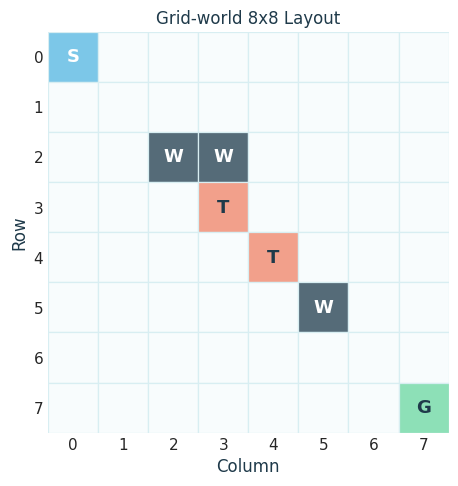

In [6]:
layout_path = NOTEBOOK_FIGURE_DIR / "grid_world_layout.png"
plot_grid_world_layout(
    learning_env,
    title="Grid-world 8x8 Layout",
    save_path=layout_path,
    show=True,
);


**Nhận xét về bố cục Grid-world:**

Hình layout cho thấy Start nằm ở góc trên trái `(0, 0)`, Goal nằm ở góc dưới phải `(7, 7)`. Hai Trap tại `(3, 3)` và `(4, 4)` được đặt gần vùng trung tâm, còn các Wall tại `(2, 2)`, `(2, 3)` và `(5, 5)` tạo ra các chướng ngại buộc agent phải đi vòng.

Bố cục này phù hợp để kiểm tra Learning Algorithms vì agent không chỉ cần tìm đường tới Goal, mà còn phải học cách tránh Trap thông qua trải nghiệm. Ở các episode đầu, agent có thể chọn action gần như ngẫu nhiên do exploration, nên dễ đi lòng vòng hoặc rơi vào Trap. Khi training tiến triển, nếu thuật toán học tốt, ta kỳ vọng episode return tăng dần, số bước trung bình giảm, success rate tăng, trap rate giảm, và policy arrows dần hướng về Goal thay vì vùng trung tâm nguy hiểm.

Khác với Planning, Learning không dùng layout để suy ra trực tiếp transition model. Layout chỉ quyết định phản hồi mà agent nhận được khi gọi `step(action)`. Vì vậy, những hình như value heatmap hoặc learned policy ở các phần sau là kết quả của quá trình học từ sample, không phải kết quả tính trực tiếp kỳ vọng từ `get_transitions()`.


## Chuẩn bị baseline đánh giá Learning Algorithms

Trước khi train các thuật toán Learning, notebook chuẩn bị hai baseline từ nhóm Planning để dùng cho **đánh giá sau training**. Các baseline này không được dùng để cập nhật agent Learning, mà chỉ đóng vai trò chuẩn tham chiếu giúp đo chất lượng kết quả.

Baseline thứ nhất là `PolicyEvaluation`. Baseline này dùng để tính $V^\pi$ cho policy cố định. Trong notebook này, khi `policy=None`, cả `PolicyEvaluation`, TD(0) và TD($\lambda$) đều được hiểu theo cùng tinh thần: policy mặc định là uniform random policy trên các action hợp lệ. Vì vậy, so sánh TD(0)/TD($\lambda$) với `PolicyEvaluation` là so sánh đúng mục tiêu prediction.

Về mặt toán học, baseline prediction thỏa Bellman Expectation Equation:

$$
V^\pi(s) = \sum_a \pi(a \mid s) \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^\pi(s')\right]
$$

TD(0) và TD($\lambda$) không tính tổng kỳ vọng này trong training. Chúng chỉ dùng sample transition để học dần một xấp xỉ của $V^\pi$. Vì thế metric phù hợp là MSE giữa value estimate học được và `baseline_v_pi`.

Baseline thứ hai là `ValueIteration`. Baseline này dùng để tính optimal value function $V^*$ và optimal policy $\pi^*$. Nó phù hợp để đánh giá các thuật toán control như SARSA và Q-learning, vì hai thuật toán này cũng hướng tới học hành vi tốt hơn qua quá trình tương tác.

Value Iteration giải Bellman Optimality Equation:

$$
V^*(s) = \max_a \sum_{s'} P(s' \mid s,a)\left[r(s,a,s') + \gamma V^*(s')\right]
$$

SARSA và Q-learning được so sánh với baseline này qua value quality, tức MSE giữa $\max_a Q(s,a)$ và $V^*(s)$, cùng policy quality, tức policy agreement giữa learned policy và $\pi^*$ trên non-terminal states.

Cần nhấn mạnh rằng baseline Planning chỉ xuất hiện ở notebook để đánh giá. Trong quá trình gọi `.train()`, các Learning Algorithms vẫn chỉ tương tác với `LearningGridWorld` thông qua `reset()` và `step(action)`. Điều này giữ đúng yêu cầu: Learning algorithms không dùng `get_transitions()` trong training.


In [7]:
baseline_env = PlanningGridWorld(seed=RANDOM_SEED)

baseline_policy_eval = PolicyEvaluation(
    env=baseline_env,
    policy=None,  # uniform random policy mặc định, cùng tinh thần với TD policy mặc định
    theta=1e-6,
    max_iterations=1000,
    verbose=0,
)
baseline_policy_eval.run()
baseline_v_pi = baseline_policy_eval.get_value_function()

baseline_vi = ValueIteration(
    env=baseline_env,
    theta=1e-6,
    max_iterations=1000,
    verbose=0,
)
baseline_vi.run()
baseline_v_star = baseline_vi.get_value_function()
baseline_pi_star = baseline_vi.get_policy()

print("Policy Evaluation baseline status:", baseline_policy_eval.get_metrics().get("status"))
print("Value Iteration baseline status:", baseline_vi.get_metrics().get("status"))

Policy Evaluation baseline status: converged
Value Iteration baseline status: converged


## Xây dựng và train các thuật toán Learning

Phần này train lần lượt bốn thuật toán thuộc nhóm Learning: **TD(0)**, **TD($\lambda$)**, **SARSA** và **Q-learning**. Các thuật toán đều được triển khai trong `agents.learning` và được gọi từ notebook thông qua interface class-based. Notebook không chứa core implementation của thuật toán; nó chỉ khởi tạo model, gọi `.train()`, lấy value/policy/metrics, rồi trực quan hóa kết quả.

Một điểm quan trọng là cần tách hai loại bài toán. **Prediction** đánh giá một policy cố định, gồm TD(0) và TD($\lambda$). **Control** học policy tốt hơn hoặc tối ưu hơn, gồm SARSA và Q-learning. Prediction trả lời câu hỏi: nếu agent đi theo policy $\pi$, mỗi state có expected return bao nhiêu? Control trả lời câu hỏi mạnh hơn: agent nên chọn action nào để tối đa hóa expected return?

### TD(0)

**TD(0)** là thuật toán temporal-difference prediction cơ bản. Nó học state-value function $V^\pi(s)$ của một policy cố định bằng cách kết hợp ý tưởng Monte Carlo và Dynamic Programming: học từ experience sample thật, nhưng vẫn bootstrap từ ước lượng hiện tại của value function.

Tại mỗi bước, agent quan sát transition $(S_t, R_{t+1}, S_{t+1})$ và tạo TD target một bước:

$$
R_{t+1} + \gamma V(S_{t+1})
$$

TD error được định nghĩa là:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

Sau đó cập nhật:

$$
V(S_t) \leftarrow V(S_t) + \alpha \delta_t
$$

Trong đó $\alpha$ là learning rate, $\gamma$ là discount factor, $V(S_t)$ là value estimate hiện tại, và $\delta_t$ đo mức sai lệch giữa estimate hiện tại và one-step target. Nếu $S_{t+1}$ là terminal state, target không bootstrap từ $V(S_{t+1})$ nữa; khi đó target chỉ còn reward kết thúc episode.

TD(0) trong notebook này dùng `policy=None`, tương ứng uniform random policy mặc định. Vì vậy, thuật toán không tìm policy tối ưu; nó chỉ học value function của policy ngẫu nhiên đó. Baseline phù hợp là $V^\pi$ từ `PolicyEvaluation`, không phải $V^*$ từ `ValueIteration`.

Quy trình thực hiện trong notebook: khởi tạo `LearningGridWorld`, khởi tạo `TDZero`, gọi `.train()`, lấy `td_zero_values` và `td_zero_metrics`, tính MSE trực tiếp so với `baseline_v_pi`, rồi vẽ MSE curve, TD error curve và heatmap của $V^\pi$ estimate.


In [8]:
td_zero_env = LearningGridWorld(seed=RANDOM_SEED)

td_zero = TDZero(
    env=td_zero_env,
    episodes=LEARNING_EPISODES,
    alpha=0.1,
    gamma=td_zero_env.gamma,
    policy=None,
    baseline_value_function=baseline_v_pi,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
    seed=RANDOM_SEED,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

td_zero_result = td_zero.train()
td_zero_values = td_zero.get_value_function()
td_zero_metrics = td_zero.get_metrics()

In [9]:
# Đánh giá trực tiếp từ model vừa train.
td_zero_mse_direct = mean_squared_error(td_zero_values, baseline_v_pi)
td_zero_metrics["notebook_mse_vs_policy_evaluation"] = td_zero_mse_direct

show_metrics(td_zero_metrics, keys=[
    "episodes",
    "environment_steps",
    "final_mean_absolute_td_error",
    "mse_vs_policy_evaluation",
    "notebook_mse_vs_policy_evaluation",
    "runtime_sec",
])

episodes: 1000
environment_steps: 85692
final_mean_absolute_td_error: 4.405539065633122
mse_vs_policy_evaluation: 11.095586612106736
notebook_mse_vs_policy_evaluation: 11.095586612106736
runtime_sec: 0.9749801970028784


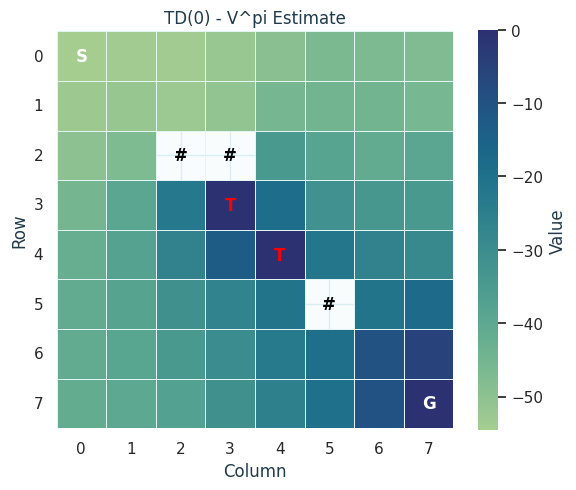

In [10]:
td0_mse_path = NOTEBOOK_FIGURE_DIR / "td_zero_mse_vs_pe.png"
td0_error_path = NOTEBOOK_FIGURE_DIR / "td_zero_td_error.png"
td0_value_path = NOTEBOOK_FIGURE_DIR / "td_zero_value_heatmap.png"

plot_td_mse_curve(
    td_zero_metrics["mse_checkpoint_episodes"],
    td_zero_metrics["mse_vs_policy_evaluation_checkpoints"],
    "TD(0) - MSE vs Policy Evaluation",
    td0_mse_path,
)
plot_td_error_curve(
    td_zero_metrics["mean_absolute_td_error_per_episode"],
    "TD(0) Mean Absolute TD Error",
    td0_error_path,
)
plot_value_heatmap(
    td_zero_values,
    td_zero_env,
    "TD(0) - V^pi Estimate",
    save_path=td0_value_path,
    show=True,
);


**Nhận xét kết quả TD(0):**

Heatmap **TD(0) - $V^\pi$ Estimate** thể hiện value function mà TD(0) học được dưới uniform random policy. Đây không phải optimal value function $V^*$, nên không nên kỳ vọng mọi state đều thể hiện đường đi tối ưu tới Goal. Khi policy là ngẫu nhiên, agent có thể đi lòng vòng, mất nhiều step cost hoặc rơi vào Trap; vì vậy phần lớn state có giá trị âm.

Mẫu giá trị trên heatmap hợp lý với bố cục môi trường. Các state gần Goal ở góc dưới phải có value cao hơn vì agent có cơ hội kết thúc episode với reward dương sau ít bước hơn. Các state xa Goal hoặc gần Trap có value thấp hơn do xác suất tích lũy step cost và reward âm cao hơn.

Đường **MSE vs Policy Evaluation** cho biết value estimate của TD(0) đang tiến gần baseline $V^\pi$ đến mức nào. Trong lần chạy notebook hiện tại, MSE giảm mạnh qua các checkpoint và kết thúc ở mức thấp hơn nhiều so với giai đoạn đầu. Điều này cho thấy sampled updates đã học được cấu trúc value function của policy ngẫu nhiên. Các con số cụ thể có thể thay đổi theo seed, số episode và môi trường chạy, nên nên đọc từ output/log của lần chạy hiện tại thay vì xem như hằng số.

Đường **Mean Absolute TD Error** thể hiện độ lớn sai số update theo episode. TD error không nhất thiết giảm trơn như Bellman residual trong Planning, vì mỗi episode là một trajectory sample và có nhiễu từ lựa chọn action ngẫu nhiên. Nếu TD error cuối vẫn còn dao động, điều đó là bình thường với learning từ sample và không tự nó cho thấy implementation sai.

So với `PolicyEvaluation`, TD(0) phải dùng nhiều environment steps hơn vì nó không có model. `PolicyEvaluation` tính kỳ vọng đầy đủ bằng Bellman expectation backup, còn TD(0) chỉ thấy một sample tại mỗi bước. Do đó, MSE khác 0 sau số episode hữu hạn là bình thường.

Về chi phí, runtime và peak memory nên được đọc cùng environment steps và giả định thông tin. TD(0) học từ sample, còn Planning dùng model đầy đủ, nên không nên so sánh runtime một cách tách rời khỏi bối cảnh.

Tóm lại, TD(0) trong notebook này thực hiện đúng vai trò prediction: học xấp xỉ $V^\pi$ cho uniform random policy, giảm MSE đáng kể so với baseline `PolicyEvaluation`, và tạo heatmap có cấu trúc phù hợp với Goal, Trap, Wall và step cost của Grid-world.


### TD($\lambda$)

**TD($\lambda$)** mở rộng TD(0) bằng **eligibility traces**. Nếu TD(0) chỉ cập nhật trực tiếp state hiện tại $S_t$, thì TD($\lambda$) cho phép TD error tại thời điểm hiện tại ảnh hưởng tới nhiều state đã được thăm gần đây trong cùng trajectory.

Trực giác của eligibility trace là: những state vừa xuất hiện gần đây có thể đã góp phần dẫn tới reward hiện tại, nên chúng cũng nên được cập nhật. State càng xa trong quá khứ thì mức ảnh hưởng càng giảm theo $\gamma\lambda$.

TD error vẫn có dạng:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

Eligibility trace cho từng state được cập nhật theo:

$$
e_t(s) = \gamma \lambda e_{t-1}(s) + \mathbf{1}\{S_t=s\}
$$

Sau đó value function được cập nhật cho mọi state theo:

$$
V(s) \leftarrow V(s) + \alpha \delta_t e_t(s)
$$

Trong đó $e_t(s)$ là eligibility trace của state $s$, còn $\lambda \in [0,1]$ điều khiển độ dài ảnh hưởng của trace. Khi $\lambda = 0$, thuật toán gần với TD(0). Khi $\lambda$ lớn hơn, update lan xa hơn về các state trước đó trong trajectory.

TD($\lambda$) vẫn là thuật toán prediction trong notebook này. Nó đánh giá cùng uniform random policy như TD(0), do đó baseline đánh giá vẫn là `PolicyEvaluation`, cụ thể là `baseline_v_pi`.

Một lợi thế tiềm năng của TD($\lambda$) là thông tin reward có thể lan truyền nhanh hơn dọc theo trajectory. Tuy nhiên, lợi thế này phụ thuộc mạnh vào $\lambda$, learning rate, số episode và cấu trúc môi trường. $\lambda$ quá cao có thể làm update nhiễu hơn hoặc tốn chi phí hơn vì nhiều state được cập nhật cùng lúc.

Quy trình thực hiện trong notebook: khởi tạo `TDLambda` với `lambda_=0.7`, gọi `.train()`, lấy value/metrics, tính MSE so với `baseline_v_pi`, rồi vẽ MSE curve, TD error curve và heatmap của $V^\pi$ estimate.


In [11]:
td_lambda_env = LearningGridWorld(seed=RANDOM_SEED)

td_lambda = TDLambda(
    env=td_lambda_env,
    episodes=LEARNING_EPISODES,
    alpha=0.1,
    gamma=td_lambda_env.gamma,
    lambda_=0.7,
    policy=None,
    baseline_value_function=baseline_v_pi,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
    seed=RANDOM_SEED,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

td_lambda_result = td_lambda.train()
td_lambda_values = td_lambda.get_value_function()
td_lambda_metrics = td_lambda.get_metrics()

In [12]:
td_lambda_mse_direct = mean_squared_error(td_lambda_values, baseline_v_pi)
td_lambda_metrics["notebook_mse_vs_policy_evaluation"] = td_lambda_mse_direct

show_metrics(td_lambda_metrics, keys=[
    "episodes",
    "lambda",
    "environment_steps",
    "final_mean_absolute_td_error",
    "mse_vs_policy_evaluation",
    "notebook_mse_vs_policy_evaluation",
    "runtime_sec",
])

episodes: 1000
lambda: 0.7
environment_steps: 85692
final_mean_absolute_td_error: 4.808031558438517
mse_vs_policy_evaluation: 9.584860316488344
notebook_mse_vs_policy_evaluation: 9.584860316488344
runtime_sec: 8.101361188004375


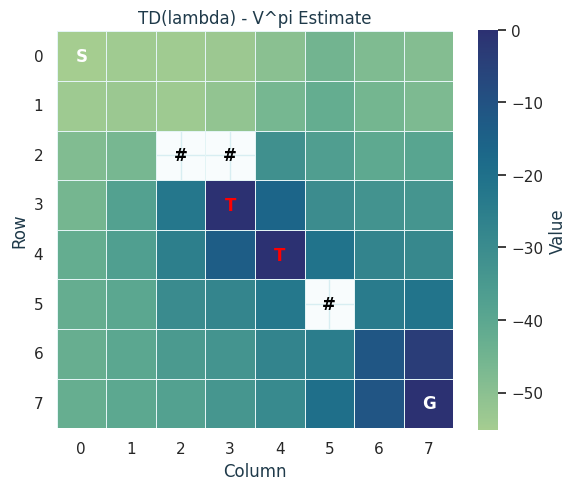

In [13]:
tdl_mse_path = NOTEBOOK_FIGURE_DIR / "td_lambda_mse_vs_pe.png"
tdl_error_path = NOTEBOOK_FIGURE_DIR / "td_lambda_td_error.png"
tdl_value_path = NOTEBOOK_FIGURE_DIR / "td_lambda_value_heatmap.png"

plot_td_mse_curve(
    td_lambda_metrics["mse_checkpoint_episodes"],
    td_lambda_metrics["mse_vs_policy_evaluation_checkpoints"],
    "TD(lambda) - MSE vs Policy Evaluation",
    tdl_mse_path,
)
plot_td_error_curve(
    td_lambda_metrics["mean_absolute_td_error_per_episode"],
    "TD(lambda) Mean Absolute TD Error",
    tdl_error_path,
)
plot_value_heatmap(
    td_lambda_values,
    td_lambda_env,
    "TD(lambda) - V^pi Estimate",
    save_path=tdl_value_path,
    show=True,
);


**Nhận xét kết quả TD($\lambda$):**

Heatmap **TD($\lambda$) - $V^\pi$ Estimate** có cấu trúc tổng thể giống TD(0): các state gần Goal có value cao hơn, các state xa Goal hoặc gần Trap có value thấp hơn. Điều này hợp lý vì cả hai thuật toán đều đang đánh giá cùng uniform random policy, không phải policy tối ưu.

Điểm khác biệt chính nằm ở cơ chế cập nhật. Với eligibility traces, một TD error tại thời điểm hiện tại không chỉ cập nhật $V(S_t)$ mà còn cập nhật các state đã đi qua gần đây. Vì vậy, thông tin reward có thể lan ngược theo trajectory nhanh hơn so với TD(0). Trong môi trường có episode dài như Grid-world dưới random policy, khả năng lan truyền này có thể giúp học nhanh hơn nếu $\lambda$ được chọn phù hợp.

Trong lần chạy notebook hiện tại, TD($\lambda$) với `lambda = 0.7` cho MSE thấp hơn TD(0). Tuy nhiên, kết quả này phụ thuộc vào $\lambda$, seed, số episode, learning rate và cấu trúc môi trường. Vì vậy, nhận xét đúng là eligibility traces có thể giúp value estimate gần baseline hơn khi chọn $\lambda$ phù hợp, không phải TD($\lambda$) luôn tốt hơn TD(0).

Khi đối chiếu với logs CLI hoặc `td_lambda_sweep.json`, cần kiểm tra cấu hình $\lambda$ đang dùng. Một giá trị $\lambda$ cao hơn có thể làm update lan xa hơn nhưng cũng có thể làm nhiễu lớn hơn hoặc tăng chi phí tính toán. Do đó, phần sensitivity theo $\lambda$ là bằng chứng quan trọng hơn một lần chạy đơn lẻ.

Về chi phí, TD($\lambda$) thường tốn runtime hơn TD(0) vì phải duy trì và cập nhật eligibility traces. Khi đánh giá thuật toán, cần đọc chất lượng MSE cùng với runtime, memory và environment steps, thay vì chỉ nhìn một metric riêng lẻ.

Tóm lại, TD($\lambda$) trong notebook này minh họa lợi ích tiềm năng của eligibility traces, đồng thời cho thấy thuật toán có thêm một hyperparameter cần kiểm soát cẩn thận.


### SARSA

**SARSA** là thuật toán control dạng **on-policy temporal-difference learning**. Tên SARSA đến từ chuỗi biến mà thuật toán sử dụng trong mỗi update:

$$
(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})
$$

Khác với TD(0), SARSA không chỉ học state-value function $V(s)$ cho một policy cố định. Nó học **action-value function** $Q(s,a)$, biểu diễn expected return khi agent ở state $s$, chọn action $a$, sau đó tiếp tục theo policy hiện tại.

Update rule của SARSA là:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma Q(S_{t+1},A_{t+1}) - Q(S_t,A_t)\right]
$$

TD target của SARSA là:

$$
R_{t+1} + \gamma Q(S_{t+1},A_{t+1})
$$

Điểm quan trọng là $A_{t+1}$ chính là action thật sự được behavior policy chọn ở state kế tiếp. Nếu behavior policy là $\epsilon$-greedy, target của SARSA cũng phản ánh khả năng agent tiếp tục exploration. Vì vậy SARSA được gọi là **on-policy**.

Trong Grid-world, tính on-policy này có ý nghĩa trực quan: nếu exploration đôi khi khiến agent đi gần Trap, SARSA có thể học value thận trọng hơn ở những vùng có rủi ro. Nó không chỉ đánh giá đường đi greedy lý tưởng, mà học theo hành vi thực tế của policy đang training.

Sau khi train, learned policy được trích xuất từ Q-table bằng greedy action:

$$
\pi(s) = \arg\max_a Q(s,a)
$$

Value function dùng để so sánh với Value Iteration được lấy từ:

$$
V_{learned}(s) = \max_a Q(s,a)
$$

Baseline phù hợp cho SARSA là `ValueIteration`, vì SARSA là thuật toán control. Notebook đo final window average return, final window success rate, final window trap rate, MSE giữa $\max_a Q(s,a)$ và $V^*$, cùng policy agreement giữa learned policy và $\pi^*$.

Quy trình thực hiện trong notebook: khởi tạo `SARSA` với `epsilon=0.1`, `alpha=0.1`, số episode và seed cố định; gọi `.train()`; lấy Q-table, value function, policy và metrics; so sánh với Value Iteration; rồi vẽ return curve, moving average return, success/trap curves, learned policy arrows và heatmap $\max_a Q(s,a)$.


In [14]:
sarsa_env = LearningGridWorld(seed=RANDOM_SEED)

sarsa = SARSA(
    env=sarsa_env,
    episodes=LEARNING_EPISODES,
    alpha=0.1,
    gamma=sarsa_env.gamma,
    epsilon=0.1,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
    window_size=NOTEBOOK_WINDOW_SIZE,
    seed=RANDOM_SEED,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

sarsa_result = sarsa.train()
sarsa_q = sarsa.get_q_table()
sarsa_values = sarsa.get_value_function()
sarsa_policy = sarsa.get_policy()
sarsa_metrics = sarsa.get_metrics()

In [15]:
non_terminal_states = [state for state in baseline_env.get_states() if not baseline_env.is_terminal(state)]

sarsa_mse_vs_vi = mean_squared_error(sarsa_values, baseline_v_star)
sarsa_agreement_vs_vi = policy_agreement(sarsa_policy, baseline_pi_star, non_terminal_states)
sarsa_metrics["notebook_mse_vs_value_iteration"] = sarsa_mse_vs_vi
sarsa_metrics["notebook_policy_agreement_vs_value_iteration"] = sarsa_agreement_vs_vi

show_metrics(sarsa_metrics, keys=[
    "episodes",
    "environment_steps",
    "training_avg_return",
    "final_window_avg_return",
    "final_window_success_rate",
    "final_window_trap_rate",
    "notebook_mse_vs_value_iteration",
    "notebook_policy_agreement_vs_value_iteration",
    "runtime_sec",
])

episodes: 1000
environment_steps: 20185
training_avg_return: -9.756
final_window_avg_return: -4.4
final_window_success_rate: 1.0
final_window_trap_rate: 0.0
notebook_mse_vs_value_iteration: 11.33977121194091
notebook_policy_agreement_vs_value_iteration: 0.6551724137931034
runtime_sec: 0.2887237729955814


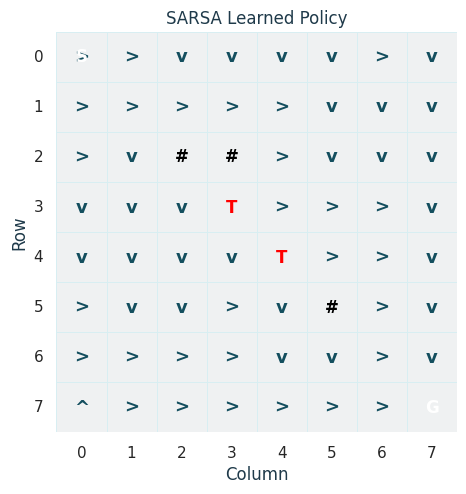

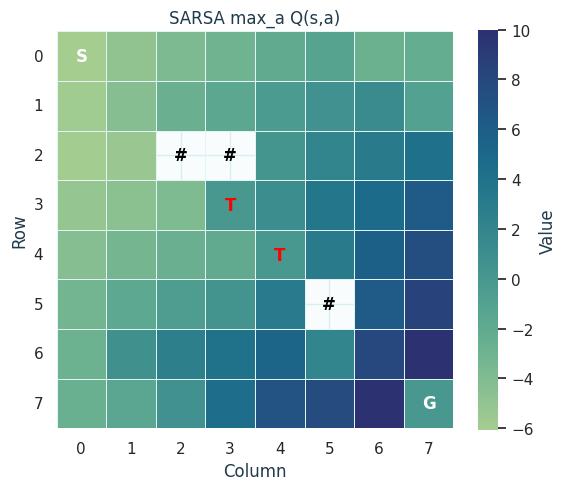

In [16]:
sarsa_return_path = NOTEBOOK_FIGURE_DIR / "sarsa_episode_returns.png"
sarsa_moving_avg_path = NOTEBOOK_FIGURE_DIR / "sarsa_moving_average_returns.png"
sarsa_success_path = NOTEBOOK_FIGURE_DIR / "sarsa_success_trap.png"
sarsa_policy_path = NOTEBOOK_FIGURE_DIR / "sarsa_policy.png"
sarsa_value_path = NOTEBOOK_FIGURE_DIR / "sarsa_value_heatmap.png"

plot_learning_curve(sarsa_metrics["episode_returns"], "SARSA Episode Returns", sarsa_return_path)
plot_moving_average(sarsa_metrics["moving_average_returns"], "SARSA Moving Average Returns", sarsa_moving_avg_path)
plot_success_trap_curves(
    sarsa_metrics["window_metric_episodes"],
    sarsa_metrics["window_success_rates"],
    sarsa_metrics["window_trap_rates"],
    "SARSA Success/Trap Rates",
    sarsa_success_path,
)
plot_policy_arrows(
    sarsa_policy,
    sarsa_env,
    "SARSA Learned Policy",
    save_path=sarsa_policy_path,
    show=True,
)
plot_value_heatmap(
    sarsa_values,
    sarsa_env,
    "SARSA max_a Q(s,a)",
    save_path=sarsa_value_path,
    show=True,
);


**Nhận xét kết quả SARSA:**

Hình **SARSA Learned Policy** cho thấy policy học được nhìn chung hướng agent sang phải hoặc xuống dưới để tiến về Goal ở `(7, 7)`, đồng thời tránh các Wall và Trap ở vùng giữa grid. Một vài mũi tên chưa trùng hoàn toàn với policy tối ưu từ Value Iteration, nhưng điều này là bình thường trong bối cảnh học từ sample hữu hạn và có exploration.

Heatmap **SARSA max_a Q(s,a)** thể hiện value suy ra từ Q-table: $V(s)=\max_a Q(s,a)$. Các vùng gần Goal có giá trị cao hơn, trong khi vùng gần Start hoặc gần Trap có giá trị thấp hơn. Điều này cho thấy Q-table đã học được cấu trúc reward của môi trường: Goal là vùng hấp dẫn, Trap là vùng cần tránh, và step cost khiến đường đi dài kém giá trị hơn.

Đường **episode returns** cho thấy quá trình học rất rõ. Các episode đầu có return thấp như `-111`, `-33`, `-41`, `-115`, `-111`, phản ánh việc agent còn exploration nhiều, đi lòng vòng hoặc rơi vào Trap. Ở các episode cuối, return chủ yếu quanh `-3` đến `-6`, phù hợp với việc agent đã tìm được đường tới Goal với số bước ít hơn.

Đường **moving average returns** giúp nhìn xu hướng ổn định hơn so với return từng episode. Khi moving average tăng dần, ta có bằng chứng rằng policy đang cải thiện qua training, không chỉ nhờ một vài episode may mắn.

Các metric cuối cho thấy SARSA đạt `final_window_avg_return = -4.40`, `final_window_success_rate = 1.0`, và `final_window_trap_rate = 0.0`. Nghĩa là trong cửa sổ cuối training, agent đi tới Goal ổn định và không rơi vào Trap. Trên toàn bộ training, `training_success_rate = 0.971` và `training_trap_rate = 0.028`, cho thấy phần lớn lỗi tập trung ở giai đoạn đầu khi policy còn đang khám phá.

So với `ValueIteration`, SARSA có `mse_vs_value_iteration = 11.34` và `policy_agreement = 0.655`. Agreement không đạt 1.0 không đồng nghĩa thuật toán thất bại. SARSA học từ sample hữu hạn, exploration làm target on-policy khác với greedy optimal target, và một số state có nhiều action gần tương đương hoặc ít được thăm nên learned action có thể khác baseline dù return cuối vẫn tốt.

Tóm lại, SARSA trong notebook này học được policy thực dụng: success rate cuối đạt 1.0, trap rate cuối bằng 0.0, return cải thiện rõ rệt, và learned policy có cấu trúc hợp lý so với bố cục Grid-world.


### Q-learning

**Q-learning** là thuật toán control dạng **off-policy temporal-difference learning**. Giống SARSA, Q-learning học action-value function $Q(s,a)$ từ sampled transitions. Điểm khác biệt nằm ở target update.

Update rule của Q-learning là:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma \max_{a'}Q(S_{t+1},a') - Q(S_t,A_t)\right]
$$

TD target là:

$$
R_{t+1} + \gamma \max_{a'}Q(S_{t+1},a')
$$

Khác với SARSA, Q-learning không dùng action thật sự được chọn ở state kế tiếp trong target. Thay vào đó, nó giả định từ $S_{t+1}$ agent sẽ chọn action greedy tốt nhất theo Q-table hiện tại.

Vì behavior policy có thể vẫn là $\epsilon$-greedy để exploration, còn target policy là greedy, Q-learning được gọi là **off-policy**. Nó học giá trị của greedy policy trong khi vẫn có thể thu thập dữ liệu bằng một behavior policy có exploration.

Sự khác biệt giữa SARSA và Q-learning có thể viết ngắn gọn như sau: SARSA dùng target $R_{t+1} + \gamma Q(S_{t+1}, A_{t+1})$, còn Q-learning dùng target $R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a')$.

Trong môi trường Grid-world, Q-learning thường có xu hướng học value gần với optimal greedy target hơn, nhưng cũng có thể nhạy với exploration và cách các state được thăm. Vì vậy cần đọc cả MSE, policy agreement, return, success rate và trap rate thay vì chỉ nhìn một metric.

Sau khi train, learned policy được lấy bằng $\pi(s)=\arg\max_a Q(s,a)$ và value estimate dùng để so sánh với Value Iteration là $V_{learned}(s)=\max_a Q(s,a)$.

Quy trình thực hiện trong notebook: khởi tạo `QLearning` với cùng `epsilon=0.1`, `alpha=0.1`, số episode và seed cố định; gọi `.train()`; lấy Q-table, value function, policy và metrics; tính MSE/policy agreement so với Value Iteration; rồi vẽ return curve, moving average return, success/trap curves, learned policy arrows và heatmap $\max_a Q(s,a)$.


In [17]:
q_env = LearningGridWorld(seed=RANDOM_SEED)

q_learning = QLearning(
    env=q_env,
    episodes=LEARNING_EPISODES,
    alpha=0.1,
    gamma=q_env.gamma,
    epsilon=0.1,
    verbose=NOTEBOOK_VERBOSE,
    log_interval=NOTEBOOK_LOG_INTERVAL,
    window_size=NOTEBOOK_WINDOW_SIZE,
    seed=RANDOM_SEED,
    max_steps_per_episode=MAX_STEPS_PER_EPISODE,
)

q_result = q_learning.train()
q_table = q_learning.get_q_table()
q_values = q_learning.get_value_function()
q_policy = q_learning.get_policy()
q_metrics = q_learning.get_metrics()

In [18]:
q_mse_vs_vi = mean_squared_error(q_values, baseline_v_star)
q_agreement_vs_vi = policy_agreement(q_policy, baseline_pi_star, non_terminal_states)
q_metrics["notebook_mse_vs_value_iteration"] = q_mse_vs_vi
q_metrics["notebook_policy_agreement_vs_value_iteration"] = q_agreement_vs_vi

show_metrics(q_metrics, keys=[
    "episodes",
    "environment_steps",
    "training_avg_return",
    "final_window_avg_return",
    "final_window_success_rate",
    "final_window_trap_rate",
    "notebook_mse_vs_value_iteration",
    "notebook_policy_agreement_vs_value_iteration",
    "runtime_sec",
])

episodes: 1000
environment_steps: 19947
training_avg_return: -9.447
final_window_avg_return: -4.43
final_window_success_rate: 1.0
final_window_trap_rate: 0.0
notebook_mse_vs_value_iteration: 9.876012332098341
notebook_policy_agreement_vs_value_iteration: 0.5689655172413793
runtime_sec: 0.3077208629983943


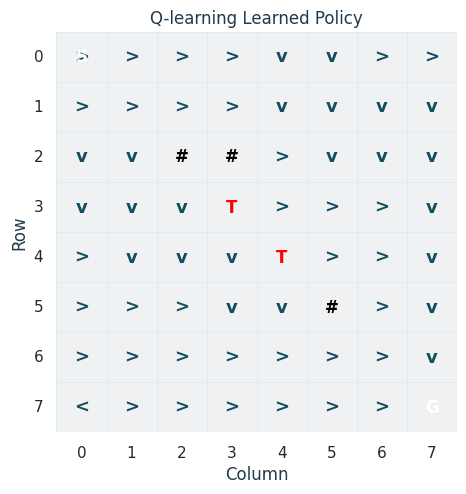

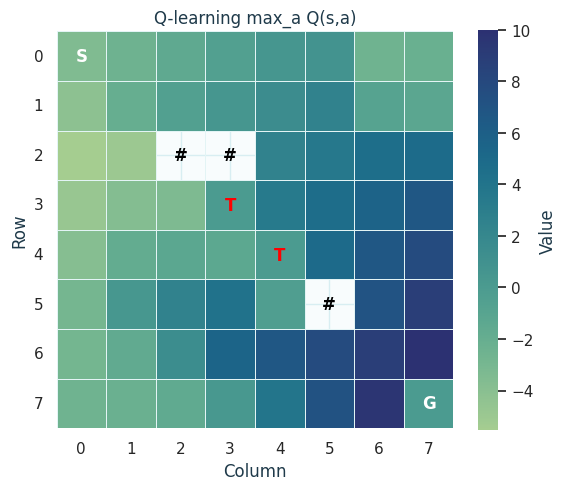

In [19]:
q_return_path = NOTEBOOK_FIGURE_DIR / "q_learning_episode_returns.png"
q_moving_avg_path = NOTEBOOK_FIGURE_DIR / "q_learning_moving_average_returns.png"
q_success_path = NOTEBOOK_FIGURE_DIR / "q_learning_success_trap.png"
q_policy_path = NOTEBOOK_FIGURE_DIR / "q_learning_policy.png"
q_value_path = NOTEBOOK_FIGURE_DIR / "q_learning_value_heatmap.png"

plot_learning_curve(q_metrics["episode_returns"], "Q-learning Episode Returns", q_return_path)
plot_moving_average(q_metrics["moving_average_returns"], "Q-learning Moving Average Returns", q_moving_avg_path)
plot_success_trap_curves(
    q_metrics["window_metric_episodes"],
    q_metrics["window_success_rates"],
    q_metrics["window_trap_rates"],
    "Q-learning Success/Trap Rates",
    q_success_path,
)
plot_policy_arrows(
    q_policy,
    q_env,
    "Q-learning Learned Policy",
    save_path=q_policy_path,
    show=True,
)
plot_value_heatmap(
    q_values,
    q_env,
    "Q-learning max_a Q(s,a)",
    save_path=q_value_path,
    show=True,
);


**Nhận xét kết quả Q-learning:**

Hình **Q-learning Learned Policy** cho thấy policy học được chủ yếu hướng agent sang phải hoặc xuống dưới để tiến về Goal ở `(7, 7)`. Các mũi tên quanh Wall và Trap thể hiện agent đã học được cách đi vòng qua chướng ngại và tránh vùng nguy hiểm sau quá trình training.

Heatmap **Q-learning max_a Q(s,a)** tăng rõ ở vùng phải/dưới gần Goal, trong khi các vùng gần Start hoặc gần Trap có giá trị thấp hơn. Đây là cấu trúc value hợp lý: state gần Goal có expected return tốt hơn, còn state xa Goal hoặc gần Trap chịu nhiều step cost và rủi ro reward âm hơn.

Đường **episode returns** cũng cải thiện mạnh. Các episode đầu có return rất thấp như `-135`, `-150`, `-36`, `-33`, `-103`, phản ánh giai đoạn agent còn khám phá và chưa biết đường đi tốt. Ở các episode cuối, return nằm quanh `-3` đến `-6`, cho thấy agent đã học được hành vi tới Goal ổn định hơn.

Metric cuối của Q-learning gần như tương đương SARSA về hiệu quả policy trong cửa sổ cuối: `final_window_avg_return = -4.43`, `final_window_success_rate = 1.0`, và `final_window_trap_rate = 0.0`. Điều này nghĩa là sau training, Q-learning cũng đạt Goal ổn định và tránh Trap trong final window.

So với `ValueIteration`, Q-learning có `mse_vs_value_iteration = 9.88`, thấp hơn SARSA (`11.34`). `final_mean_absolute_td_error = 0.113` cũng thấp hơn SARSA (`0.435`). Trong lần chạy này, value estimate của Q-learning gần $V^*$ hơn theo MSE.

Tuy nhiên, `policy_agreement_vs_value_iteration = 0.569`, thấp hơn SARSA (`0.655`). Đây là điểm cần diễn giải cẩn thận: value MSE và policy agreement đo hai khía cạnh khác nhau. Một Q-table có thể tạo ra value gần baseline nhưng vẫn chọn action khác ở một số state, đặc biệt nếu các action có giá trị gần nhau hoặc state đó ít được thăm trong training.

Vì Q-learning là off-policy, target update luôn dùng greedy action ở next state. Điều này giúp nó hướng tới optimal greedy value, nhưng không đảm bảo policy agreement đạt 1.0 sau số episode hữu hạn. Để kết luận mạnh hơn, cần thêm nhiều episode, giảm dần epsilon, hoặc chạy multi-seed evaluation.

Tóm lại, Q-learning trong notebook này học được policy hiệu quả: final success rate đạt 1.0, trap rate bằng 0.0, return cuối tốt, và value estimate gần baseline Value Iteration hơn SARSA theo MSE trong lần chạy hiện tại.


## Đánh giá và so sánh Learning Algorithms

Phần này tổng hợp kết quả của bốn thuật toán Learning theo đúng vai trò của từng nhóm. Mục tiêu không phải xếp hạng đơn giản tất cả thuật toán vào một bảng chung, mà là so sánh đúng bài toán mà mỗi thuật toán đang giải.

Các so sánh hợp lệ trong notebook gồm:

- **TD(0) vs TD($\lambda$)**: cả hai đều là prediction algorithms, cùng đánh giá uniform random policy, nên có thể so sánh MSE vs `PolicyEvaluation`, TD error, runtime và environment steps.
- **SARSA vs Q-learning**: cả hai đều là control algorithms, cùng học Q-table từ sample, nên có thể so sánh return, success rate, trap rate, MSE vs `ValueIteration`, policy agreement và environment steps.
- **TD methods vs planning baseline** chỉ dùng theo nghĩa prediction baseline: TD(0)/TD($\lambda$) học xấp xỉ $V^\pi$, còn `PolicyEvaluation` tính $V^\pi$ bằng model.
- **Control methods vs planning baseline** chỉ dùng theo nghĩa optimal control baseline: SARSA/Q-learning học xấp xỉ policy/value tốt, còn `ValueIteration` tính $V^*$ và $\pi^*$ bằng model.

Các so sánh nên tránh: không so sánh TD(0) trực tiếp với Value Iteration như thể cả hai cùng tìm policy tối ưu; không kết luận Learning kém Planning chỉ vì Learning cần nhiều environment steps hơn; và không dùng một metric duy nhất, ví dụ MSE, để kết luận toàn bộ chất lượng control policy.

Trong phần này, notebook tạo dictionary `learning_comparison` gồm MSE của TD(0)/TD($\lambda$) so với `PolicyEvaluation`, final window return và success rate của SARSA/Q-learning, MSE của SARSA/Q-learning so với `ValueIteration`, và policy agreement của SARSA/Q-learning so với policy tối ưu.

Các biểu đồ bar ở cell sau giúp đọc nhanh sự khác biệt giữa các thuật toán, nhưng phần diễn giải cần đặt trong bối cảnh sample-based learning, single seed và hyperparameters hiện tại.


In [20]:
learning_comparison = {
    "TDZero_mse_vs_PE": td_zero_metrics.get("notebook_mse_vs_policy_evaluation"),
    "TDLambda_mse_vs_PE": td_lambda_metrics.get("notebook_mse_vs_policy_evaluation"),
    "SARSA_window_return": sarsa_metrics.get("final_window_avg_return"),
    "QLearning_window_return": q_metrics.get("final_window_avg_return"),
    "SARSA_window_success": sarsa_metrics.get("final_window_success_rate"),
    "QLearning_window_success": q_metrics.get("final_window_success_rate"),
    "SARSA_mse_vs_VI": sarsa_metrics.get("notebook_mse_vs_value_iteration"),
    "QLearning_mse_vs_VI": q_metrics.get("notebook_mse_vs_value_iteration"),
    "SARSA_policy_agreement": sarsa_metrics.get("notebook_policy_agreement_vs_value_iteration"),
    "QLearning_policy_agreement": q_metrics.get("notebook_policy_agreement_vs_value_iteration"),
}
show_metrics(learning_comparison)

TDZero_mse_vs_PE: 11.095586612106736
TDLambda_mse_vs_PE: 9.584860316488344
SARSA_window_return: -4.4
QLearning_window_return: -4.43
SARSA_window_success: 1.0
QLearning_window_success: 1.0
SARSA_mse_vs_VI: 11.33977121194091
QLearning_mse_vs_VI: 9.876012332098341
SARSA_policy_agreement: 0.6551724137931034
QLearning_policy_agreement: 0.5689655172413793


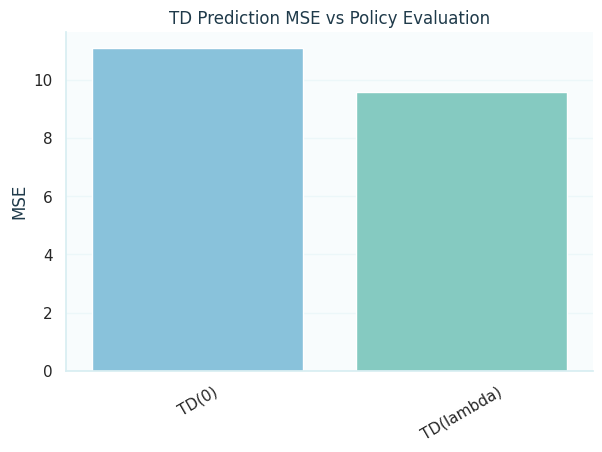

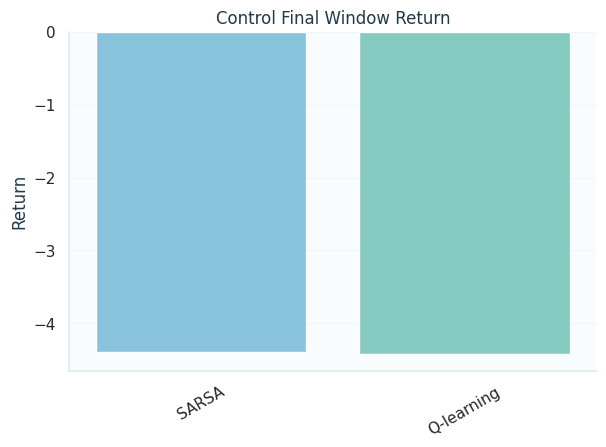

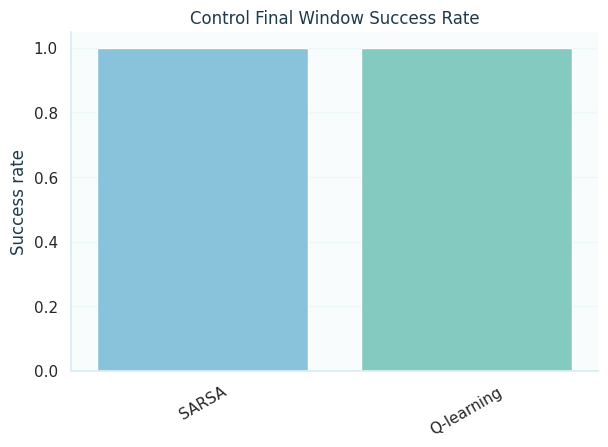

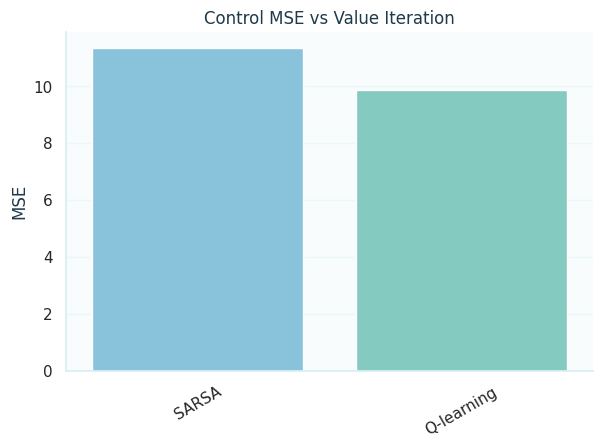

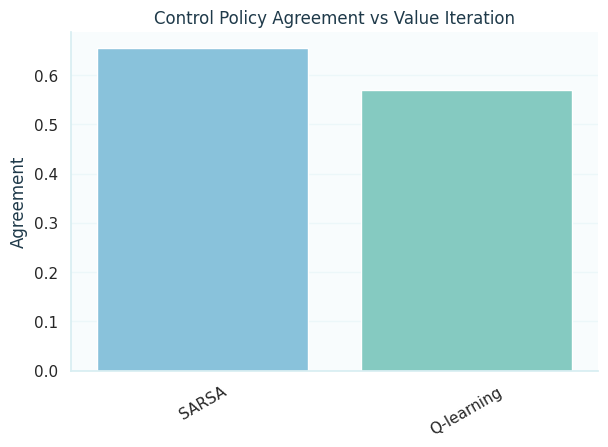

In [21]:
td_mse_comparison_path = NOTEBOOK_FIGURE_DIR / "td_mse_vs_policy_evaluation_comparison.png"
control_return_path = NOTEBOOK_FIGURE_DIR / "control_window_return_comparison.png"
control_success_path = NOTEBOOK_FIGURE_DIR / "control_window_success_comparison.png"
control_agreement_path = NOTEBOOK_FIGURE_DIR / "control_policy_agreement_comparison.png"
control_mse_path = NOTEBOOK_FIGURE_DIR / "control_mse_vs_value_iteration_comparison.png"

plot_comparison_bar(
    {
        "TD(0)": learning_comparison["TDZero_mse_vs_PE"],
        "TD(lambda)": learning_comparison["TDLambda_mse_vs_PE"],
    },
    "TD Prediction MSE vs Policy Evaluation",
    save_path=td_mse_comparison_path,
    ylabel="MSE",
    show=True,
)
plot_comparison_bar(
    {
        "SARSA": learning_comparison["SARSA_window_return"],
        "Q-learning": learning_comparison["QLearning_window_return"],
    },
    "Control Final Window Return",
    save_path=control_return_path,
    ylabel="Return",
    show=True,
)
plot_comparison_bar(
    {
        "SARSA": learning_comparison["SARSA_window_success"],
        "Q-learning": learning_comparison["QLearning_window_success"],
    },
    "Control Final Window Success Rate",
    save_path=control_success_path,
    ylabel="Success rate",
    show=True,
)
plot_comparison_bar(
    {
        "SARSA": learning_comparison["SARSA_mse_vs_VI"],
        "Q-learning": learning_comparison["QLearning_mse_vs_VI"],
    },
    "Control MSE vs Value Iteration",
    save_path=control_mse_path,
    ylabel="MSE",
    show=True,
)
plot_comparison_bar(
    {
        "SARSA": learning_comparison["SARSA_policy_agreement"],
        "Q-learning": learning_comparison["QLearning_policy_agreement"],
    },
    "Control Policy Agreement vs Value Iteration",
    save_path=control_agreement_path,
    ylabel="Agreement",
    show=True,
);


**Nhận xét so sánh Learning Algorithms:**

Với nhóm prediction, kết quả trong lần chạy notebook hiện tại cho thấy TD($\lambda$) với `lambda = 0.7` có MSE thấp hơn TD(0). Điều này phù hợp với trực giác rằng eligibility traces có thể giúp tín hiệu reward lan ngược nhanh hơn qua trajectory trong một số cấu hình.

Tuy nhiên, kết quả này cần được đọc cùng sensitivity. Khi đổi $\lambda$, seed hoặc số episode, thứ hạng giữa TD(0) và TD($\lambda$) có thể thay đổi. Vì vậy, kết luận đúng không phải là TD($\lambda$) luôn tốt hơn TD(0), mà là TD($\lambda$) có thể tốt hơn khi chọn $\lambda$ phù hợp, đồng thời nhạy hơn với hyperparameter.

Với nhóm control, final window return của SARSA và Q-learning gần như hòa nhau: SARSA khoảng `-4.40`, Q-learning khoảng `-4.43`. Cả hai đều đạt `final_window_success_rate = 1.0` và `final_window_trap_rate = 0.0`, nghĩa là trong giai đoạn cuối training, cả hai đều học được policy đưa agent tới Goal ổn định và tránh Trap.

Xét toàn bộ training, Q-learning nhỉnh hơn nhẹ về average return (`-9.447` so với SARSA `-9.756`) và success rate (`0.975` so với `0.971`). Chênh lệch này nhỏ trong single seed, nên không nên diễn giải quá mạnh nếu chưa có multi-seed analysis đầy đủ.

Về value quality so với `ValueIteration`, Q-learning có MSE thấp hơn SARSA (`9.88` so với `11.34`). Điều này cho thấy trong lần chạy hiện tại, $\max_a Q(s,a)$ của Q-learning gần $V^*$ hơn theo trung bình bình phương sai số.

Về policy agreement, SARSA lại cao hơn Q-learning (`0.655` so với `0.569`). Đây là ví dụ tốt cho thấy MSE và policy agreement không đo cùng một thứ. MSE đo độ gần của value function, còn policy agreement đo tỷ lệ state chọn cùng action với policy từ Value Iteration. Nếu nhiều action có giá trị gần nhau, hoặc state ít được thăm, policy có thể khác action baseline dù value vẫn gần.

Về chi phí, SARSA và Q-learning đều khá nhẹ trong cấu hình hiện tại, nhưng các số runtime cụ thể phụ thuộc môi trường chạy. TD methods thường dùng nhiều environment steps hơn trong notebook này vì prediction dưới uniform random policy tạo ra episode dài hơn và không chủ động tối ưu đường đi tới Goal.

Không nên dùng runtime để kết luận Learning kém Planning. Planning có quyền truy cập model đầy đủ và có thể tính Bellman backup trực tiếp. Learning chỉ thấy sampled transitions, nên chi phí environment steps là một phần bản chất của bài toán. So sánh công bằng hơn là tách riêng chất lượng value/policy, số episode và environment steps, runtime/CPU/memory, và giả định thông tin mà thuật toán được phép dùng.

Tóm lại, trong lần chạy notebook này TD($\lambda$) với `lambda = 0.7` cho MSE tốt hơn TD(0), nhưng kết luận này phụ thuộc $\lambda$ và cần đọc cùng sensitivity. Với control, SARSA và Q-learning đều học được policy thành công ở cuối training; Q-learning gần hơn về value MSE, còn SARSA cao hơn về policy agreement trong lần chạy single-seed hiện tại.


## Thực nghiệm mở rộng tùy chọn

Các phân tích dưới đây là optional, dùng khi cần kiểm tra sensitivity hoặc độ ổn định của Learning Algorithms. Vì Learning phụ thuộc vào sampled trajectories, kết quả từ một seed và một bộ hyperparameter không nên được xem là kết luận tuyệt đối.

Ba nhóm kiểm tra mở rộng trong project gồm:

1. **TD($\lambda$) sweep**: thử nhiều giá trị $\lambda$ để xem eligibility traces ảnh hưởng MSE như thế nào.
2. **Control epsilon sensitivity**: thử nhiều giá trị `epsilon` cho SARSA và Q-learning để đánh giá ảnh hưởng của exploration.
3. **Multi-seed smoke test**: chạy nhiều random seeds để kiểm tra độ ổn định sơ bộ.

Trong notebook này, cell bên dưới chạy trực tiếp ba nhóm thí nghiệm trên với `verbose=2`. Cách này tương đương phần optional của CLI, nhưng gọi thẳng các hàm trong `scripts/run_experiments.py` nên không chạy lại toàn bộ experiment chính nhiều lần.

Nếu muốn chạy bằng CLI riêng, có thể dùng:

```bash
python3 scripts/run_experiments.py --verbose 2 --run-td-lambda-sweep
python3 scripts/run_experiments.py --verbose 2 --run-control-sensitivity
python3 scripts/run_experiments.py --verbose 2 --run-multiseed-smoke
```

**TD($\lambda$) sweep** giúp trả lời câu hỏi: trace dài hơn có giúp value prediction tốt hơn không? Về lý thuyết, $\lambda$ lớn hơn cho phép reward lan xa hơn về các state trước đó, nhưng cũng có thể làm update nhiễu hơn. Vì vậy, $\lambda$ cần được kiểm tra thực nghiệm thay vì chọn tùy ý.

**Control epsilon sensitivity** giúp kiểm tra trade-off exploration/exploitation. Nếu `epsilon` quá cao, agent tiếp tục chọn nhiều action ngẫu nhiên, có thể làm final return thấp hơn. Nếu `epsilon` quá thấp, agent có thể khai thác quá sớm và bỏ lỡ đường đi tốt. Trong Grid-world, metric cần quan sát gồm final window return, success rate, trap rate và số bước trung bình.

**Multi-seed smoke test** giúp giảm rủi ro kết luận dựa trên một seed may mắn hoặc kém may mắn. Với Learning Algorithms, random seed ảnh hưởng đến trajectory, action exploration và thứ tự state được cập nhật. Smoke test với số seed nhỏ chưa đủ để kết luận thống kê mạnh, nhưng giúp phát hiện kết quả quá bất ổn.

Các kết quả optional sẽ được ghi vào:

- `logs/learning/td_lambda_sweep.json`
- `logs/learning/control_sensitivity.json`
- `logs/learning/multiseed_smoke.json`
- `report/figures/learning/td_lambda_sensitivity_mse.png`
- `report/figures/learning/sarsa_epsilon_sensitivity_return.png`
- `report/figures/learning/q_learning_epsilon_sensitivity_return.png`

Các file trên có thể bị ghi đè khi chạy lại cell optional.


In [22]:
from contextlib import contextmanager
import os
from pathlib import Path

from scripts.run_experiments import (
    run_control_sensitivity,
    run_multiseed_smoke,
    run_td_lambda_sweep,
)


@contextmanager
def working_directory(path):
    previous_cwd = Path.cwd()
    os.chdir(path)
    try:
        yield
    finally:
        os.chdir(previous_cwd)


OPTIONAL_VERBOSE = 2

# Run from project root so logs/ and report/ are created in the repo root,
# not under notebooks/.
with working_directory(PROJECT_ROOT):
    td_lambda_sweep = run_td_lambda_sweep(
        verbose=OPTIONAL_VERBOSE,
        log_interval=NOTEBOOK_LOG_INTERVAL,
        window_size=NOTEBOOK_WINDOW_SIZE,
    )
    control_sensitivity = run_control_sensitivity(
        verbose=OPTIONAL_VERBOSE,
        log_interval=NOTEBOOK_LOG_INTERVAL,
        window_size=NOTEBOOK_WINDOW_SIZE,
    )
    multiseed_smoke = run_multiseed_smoke(
        verbose=OPTIONAL_VERBOSE,
        window_size=NOTEBOOK_WINDOW_SIZE,
    )

print("TD(lambda) best lambda:", td_lambda_sweep.get("best_lambda_by_mse"))
print("SARSA best epsilon:", control_sensitivity.get("sarsa_best_epsilon_by_window_return"))
print("Q-learning best epsilon:", control_sensitivity.get("q_learning_best_epsilon_by_window_return"))
print("Multi-seed aggregate:", multiseed_smoke.get("aggregate"))


[TDLambda] Training progress
  episode | td_error   | mse_vs_pe  | env_steps
  ------- | ---------- | ---------- | ---------
      100 |  1.386e+00 |  7.045e+02 |      8816
      200 |  1.386e+00 |  3.969e+02 |     16801
      300 |  1.659e+00 |  2.196e+02 |     25448
[TDLambda] Training progress
  episode | td_error   | mse_vs_pe  | env_steps
  ------- | ---------- | ---------- | ---------
      100 |  1.497e+00 |  5.393e+02 |      8816
      200 |  1.475e+00 |  2.572e+02 |     16801
      300 |  1.697e+00 |  1.206e+02 |     25448
[TDLambda] Training progress
  episode | td_error   | mse_vs_pe  | env_steps
  ------- | ---------- | ---------- | ---------
      100 |  1.620e+00 |  3.940e+02 |      8816
      200 |  1.542e+00 |  1.579e+02 |     16801
      300 |  1.709e+00 |  6.302e+01 |     25448
[TDLambda] Training progress
  episode | td_error   | mse_vs_pe  | env_steps
  ------- | ---------- | ---------- | ---------
      100 |  1.762e+00 |  2.210e+02 |      8816
      200 |  1.711e+

## Tổng kết Learning Algorithms

Trong notebook này, ta đã lần lượt xây dựng, train và đánh giá bốn thuật toán thuộc nhóm **Learning Algorithms** trên môi trường Grid-world Navigation 8x8:

1. **TD(0)**
2. **TD($\lambda$)**
3. **SARSA**
4. **Q-learning**

Điểm chung của các thuật toán Learning là chúng học từ sampled transitions thay vì dùng trực tiếp transition model. Trong quá trình training, agent chỉ tương tác với môi trường qua `reset()` và `step(action)`. Điều này khác với Planning, nơi agent có thể gọi `get_transitions(state, action)` để tính Bellman backup từ model đầy đủ.

**TD(0)** được dùng cho bài toán prediction. Thuật toán học $V^\pi$ của uniform random policy bằng one-step TD update:

$$
\delta_t = R_{t+1} + \gamma V(S_{t+1}) - V(S_t)
$$

$$
V(S_t) \leftarrow V(S_t) + \alpha \delta_t
$$

Trong lần chạy notebook này, TD(0) giảm MSE rõ rệt so với các checkpoint đầu và tiến gần hơn tới `PolicyEvaluation` sau quá trình training. TD error cuối vẫn còn dao động, điều này hợp lý vì thuật toán học từ sample chứ không tính kỳ vọng đầy đủ như Planning.

**TD($\lambda$)** mở rộng TD(0) bằng eligibility traces:

$$
e_t(s) = \gamma \lambda e_{t-1}(s) + \mathbf{1}\{S_t=s\}
$$

$$
V(s) \leftarrow V(s) + \alpha \delta_t e_t(s)
$$

Với `lambda = 0.7`, notebook cho kết quả tốt hơn TD(0) trong lần chạy này. Tuy nhiên, các logs/sensitivity với giá trị $\lambda$ khác có thể cho kết quả khác, nên kết luận đúng là TD($\lambda$) có thể giúp khi $\lambda$ phù hợp, nhưng nhạy với lựa chọn hyperparameter.

**SARSA** là thuật toán control on-policy. Nó cập nhật Q-table bằng action thật sự được chọn ở state kế tiếp. Kết quả cho thấy SARSA học được policy ổn định ở cuối training: final window success rate đạt `1.0`, trap rate bằng `0.0`, return khoảng `-4.40`, và policy agreement với Value Iteration khoảng `0.655`. Đây là kết quả tốt cho một thuật toán học từ sample hữu hạn với exploration.

**Q-learning** là thuật toán control off-policy. Nó dùng greedy target ở state kế tiếp:

$$
Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma \max_{a'}Q(S_{t+1},a') - Q(S_t,A_t)\right]
$$

Trong lần chạy này, Q-learning cũng đạt final window success rate `1.0` và trap rate `0.0`. So với SARSA, Q-learning có MSE thấp hơn so với Value Iteration (`9.88` so với `11.34`), nhưng policy agreement thấp hơn (`0.569` so với `0.655`). Điều này cho thấy value quality và exact action agreement cần được đọc như hai metric khác nhau.

Phần so sánh cuối notebook nhấn mạnh các nguyên tắc diễn giải quan trọng: TD(0) và TD($\lambda$) nên so với `PolicyEvaluation`, SARSA và Q-learning nên so với `ValueIteration`, không nên nói Learning kém Planning chỉ vì cần nhiều sample hoặc runtime khác nhau, và single-seed result nên được hỗ trợ thêm bằng sensitivity/multi-seed checks nếu muốn kết luận chắc hơn.

Tổng thể, notebook cho thấy các thuật toán Learning đã học được cấu trúc của Grid-world từ sampled interaction. TD methods ước lượng được value function của policy cố định; SARSA và Q-learning học được policy đưa agent tới Goal ổn định trong giai đoạn cuối training. Các baseline Planning giúp định lượng chất lượng sau training, nhưng không làm thay đổi bản chất model-free của quá trình học.
